In [4]:
%config InlineBackend.figure_format = 'svg'

In [8]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from PyLTSpice import RawRead

# ============================================
# Load Configuration
# ============================================
with open("config.yaml", "r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

# ============================================
# Output Directory Setup
# ============================================

REPORT_DIR = Path(config["paths"]["report_directory"])
REPORT_DIR.mkdir(exist_ok=True)

print(f"Reports directory ready at: {os.path.abspath(REPORT_DIR)}")

Reports directory ready at: /workspace/05_Verification/ElectronicHardware/Simulation/Analog/ANA-002_OutputDynamicRange/04_Report


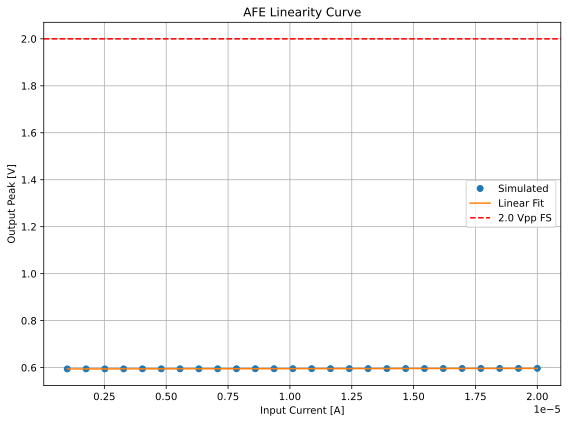

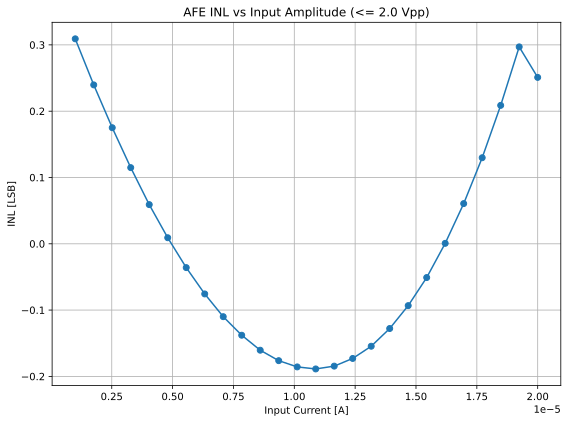


========== AFE LINEARITY REPORT ==========
Full-Scale Voltage:      2.00 Vpp
Max Output Observed:     0.5967 V
------------------------------------------
Max INL (Volts):         1.509434e-04 V
Max INL (Percent FS):    0.007547 %
Max INL (LSB):           0.3091 LSB
------------------------------------------
RESULT: INVALID (Full-scale 2.0 Vpp not reached)



In [ ]:
import os

# ============================================================
# Configuration
# ============================================================
ADC_BITS = int(config["adc"]["resolution"])
FULL_SCALE_VOLTAGE = float(config["adc"]["full_scale_voltage"])  # 2.0 Vpp expected
ADC_LSB = FULL_SCALE_VOLTAGE / (2**ADC_BITS)

# ============================================================
# Load RAW File
# ============================================================
raw_path = config["simulation"]["raw_file"]
raw = RawRead(raw_path)

time = raw.get_trace(config["simulation"]["trace"]["time"]).get_wave(0)
steps = raw.get_steps()
num_steps = len(steps)

# ============================================================
# Extract input amplitudes (from RAW if available)
# ============================================================
if isinstance(steps[0], dict) and "Iamp" in steps[0]:
    input_amplitudes = np.array([step["Iamp"] for step in steps])
else:
    # Assumes: .step param Iamp 1u 20u 1u
    input_amplitudes = np.linspace(1e-6, 20e-6, num_steps)

# ============================================================
# Extract peak output per step (polarity independent)
# ============================================================
output_peaks = []

for step_index in range(num_steps):
    vout_p = raw.get_trace(config["simulation"]["trace"]["output_positive"]).get_wave(
        step_index
    )
    vout_n = raw.get_trace(config["simulation"]["trace"]["output_negative"]).get_wave(
        step_index
    )

    vdiff = np.real(vout_p - vout_n)

    # Polarity-independent peak detection
    peak_value = np.max(np.abs(vdiff))

    output_peaks.append(peak_value)

output_peaks = np.array(output_peaks)

# ============================================================
# Linear Fit (all data)
# ============================================================
coeffs = np.polyfit(input_amplitudes, output_peaks, 1)
fit_line = np.polyval(coeffs, input_amplitudes)

# ============================================================
# INL Calculation (referenced to fixed full-scale)
# ============================================================
inl_volts = output_peaks - fit_line
inl_percent = (inl_volts / FULL_SCALE_VOLTAGE) * 100
inl_lsb = inl_volts / ADC_LSB

# ============================================================
# Apply valid range: Vout <= 2.0 Vpp
# ============================================================
valid_idx = output_peaks <= FULL_SCALE_VOLTAGE

if not np.any(valid_idx):
    raise RuntimeError("No valid samples within 0–2.0 Vpp range")

inl_volts_valid = inl_volts[valid_idx]
inl_percent_valid = inl_percent[valid_idx]
inl_lsb_valid = inl_lsb[valid_idx]

# ============================================================
# Metrics
# ============================================================
max_inl_volts = np.max(np.abs(inl_volts_valid))
max_inl_percent = np.max(np.abs(inl_percent_valid))
max_inl_lsb = np.max(np.abs(inl_lsb_valid))

# ============================================================
# Plot Linearity Curve
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(input_amplitudes, output_peaks, "o", label="Simulated")
plt.plot(input_amplitudes, fit_line, "-", label="Linear Fit")
plt.axhline(FULL_SCALE_VOLTAGE, color="red", linestyle="--", label="2.0 Vpp FS")
plt.xlabel("Input Current [A]")
plt.ylabel("Output Peak [V]")
plt.title("AFE Linearity Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(REPORT_DIR / "AFE_Linearity_Curve.svg", format="svg")
plt.show()

# ============================================================
# Plot INL
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(input_amplitudes[valid_idx], inl_lsb_valid, "o-")
plt.xlabel("Input Current [A]")
plt.ylabel("INL [LSB]")
plt.title("AFE INL vs Input Amplitude (<= 2.0 Vpp)")
plt.grid(True)
plt.tight_layout()

plt.savefig(REPORT_DIR / "AFE_INL.svg", format="svg")
plt.show()

# ============================================================
# Summary + Verification Result
# ============================================================
print("\n========== AFE LINEARITY REPORT ==========")
print(f"Full-Scale Voltage:      {FULL_SCALE_VOLTAGE:.2f} Vpp")
print(f"Max Output Observed:     {np.max(output_peaks):.4f} V")
print("------------------------------------------")
print(f"Max INL (Volts):         {max_inl_volts:.6e} V")
print(f"Max INL (Percent FS):    {max_inl_percent:.6f} %")
print(f"Max INL (LSB):           {max_inl_lsb:.4f} LSB")
print("------------------------------------------")

INL_LIMIT = 0.1  # percent

if np.max(output_peaks) < FULL_SCALE_VOLTAGE:
    print("RESULT: INVALID (Full-scale 2.0 Vpp not reached)")

elif max_inl_percent <= INL_LIMIT:
    print("RESULT: PASS (ANA-002)")

else:
    print("RESULT: FAIL (ANA-002)")

print("==========================================\n")